# Module 6: Supervised Learning of Hiking Trails

In [ ]:
import pandas as pd
import numpy as np

In [ ]:

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [19]:
df = pd.read_csv('Trails_data.csv')
print(df.shape)
df.head()

(842, 11)


,Trail_name,link_AllTrails,image,Difficulty,Average_rating,number_of_reviews,Location,Location.1,Length,description,Tags
0,Triund Trek Loop,https://www.alltrails.com/trail/india/himachal...,https://www.alltrails.com/api/alltrails/v2/tra...,Hard,4.6,(72),"Dharmshala, Himachal Pradesh, India",NaN,Length: 19.0 km,This is one of the top tourist destinations in...,"Camping, Bird watching, Hiking, Snowshoeing, B..."
1,Lamadugh Natural Valley Trek,https://www.alltrails.com/trail/india/himachal...,https://www.alltrails.com/api/alltrails/v2/tra...,Hard,4.3,(86),NaN,Manali Wildlife Sanctuary,Length: 11.4 km,Lamadugh (Also known as Lamadug) is a popular ...,"Camping, Bird watching, Hiking, Snowshoeing, B..."
2,Sinhagad Fort,https://www.alltrails.com/trail/india/maharash...,https://www.alltrails.com/api/alltrails/v2/tra...,Hard,4.8,(227),"Velhe, Maharashtra, India",NaN,Length: 8.0 km,Sinhagad Fort is a fort that was built 2000 ye...,"Hiking, Walking, Partially paved, Forest, View..."
3,Blackberry Hill - Attukad Falls Loop,https://www.alltrails.com/trail/india/kerala/b...,https://www.alltrails.com/api/alltrails/v2/tra...,Moderate,4.6,(64),"Munnar, Kerala, India",NaN,Length: 9.3 kmEst. 3h 10m,This is a beautiful mountain biking trail in M...,"Hiking, Mountain biking, Partially paved, Fore..."
4,Triund Hill Trek,https://www.alltrails.com/trail/india/himachal...,https://www.alltrails.com/api/alltrails/v2/tra...,Hard,4.6,(73),"Dharamsala, Himachal Pradesh, India",NaN,Length: 9.5 km,This is one of the top tourist destinations in...,"Camping, Bird watching, Hiking, Snowshoeing, W..."


# Cleaning and binarize the data

In [20]:
df['length_km'] = df['Length'].str.extract(r'([\d.]+)').astype(float)
df['review_count'] = df['number_of_reviews'].str.replace('(', '').str.replace(')', '').astype(int)
df['difficulty_encoded'] = df['Difficulty'].map({'Easy': 0, 'Moderate': 1, 'Hard': 2})

df['has_views'] = df['Tags'].str.contains('Views').astype(int)
df['has_waterfall'] = df['Tags'].str.contains('Waterfall').astype(int)
df['has_camping'] = df['Tags'].str.contains('Camping').astype(int)
df['is_dog_friendly'] = df['Tags'].str.contains('Dog friendly').astype(int)
df['is_kid_friendly'] = df['Tags'].str.contains('Kid friendly').astype(int)

def bin_rating(r):
    if r < 4.3:
        return 'Low'
    elif r < 4.7:
        return 'Medium'
    else:
        return 'High'

df['rating_tier'] = df['Average_rating'].apply(bin_rating)
print(df['rating_tier'].value_counts())

rating_tier
High      408
Medium    239
Low       195
Name: count, dtype: int64


# Features

In [21]:
features = ['length_km', 'difficulty_encoded', 'review_count',
            'has_views', 'has_waterfall', 'has_camping',
            'is_dog_friendly', 'is_kid_friendly']

X = df[features].fillna(0)
y = df['rating_tier']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 673
Testing samples: 169


# Training

In [22]:
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    print(f"{name}: Train = {train_acc:.3f}, Test = {test_acc:.3f}")

Decision Tree: Train = 0.579, Test = 0.485
Random Forest: Train = 0.979, Test = 0.592
Logistic Regression: Train = 0.511, Test = 0.456


# Wrongs

In [23]:
best_model = models['Random Forest']
y_pred = best_model.predict(X_test)

print(classification_report(y_test, y_pred))

results = X_test.copy()
results['actual'] = y_test.values
results['predicted'] = y_pred

wrong = results[results['actual'] != results['predicted']]
wrong_trails = df.loc[wrong.index, ['Trail_name', 'Difficulty', 'Average_rating', 'length_km', 'review_count']]
wrong_trails['actual'] = wrong['actual'].values
wrong_trails['predicted'] = wrong['predicted'].values

print(f"\nTotal wrong: {len(wrong)} out of {len(y_test)}")
print()
print(wrong_trails.head(5).to_string())

              precision    recall  f1-score   support

        High       0.68      0.74      0.71        82
         Low       0.39      0.41      0.40        39
      Medium       0.61      0.48      0.53        48

    accuracy                           0.59       169
   macro avg       0.56      0.54      0.55       169
weighted avg       0.59      0.59      0.59       169


Total wrong: 69 out of 169

              Trail_name Difficulty  Average_rating  length_km  review_count  actual predicted
320        Matheran Loop       Hard             4.5       14.3             3  Medium       Low
744     Sadashivgad Fort   Moderate             4.2        2.6             4     Low      High
772  Shrikot - Nag Tibba       Hard             5.0       13.7             2    High    Medium
493         Sarakki Lake       Easy             5.0        2.6             2    High       Low
446   Kalkere Lake Trail       Easy             4.3        7.4             4  Medium      High


In [24]:
for name, model in models.items():
    model.fit(X_train, y_train)
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    print(f"{name}: Train = {train_acc:.3f}, Test = {test_acc:.3f}")

Decision Tree: Train = 0.579, Test = 0.485
Random Forest: Train = 0.979, Test = 0.592
Logistic Regression: Train = 0.511, Test = 0.456


# GRAPHS

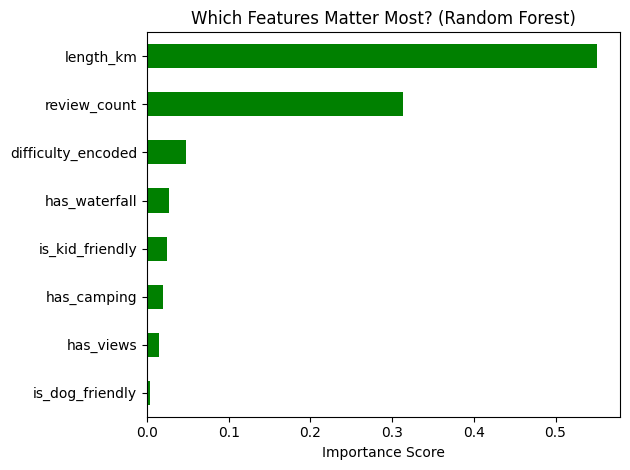

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance
importances = pd.Series(best_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='green')
plt.title('Which Features Matter Most? (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

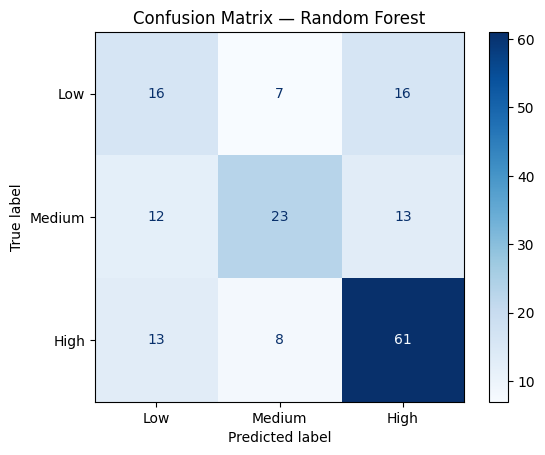

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest')
plt.show()